In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 110.1 MB/s eta 0:00:00


In [2]:
######################################################################
# 0. (Only once) – install Pennylane if your kernel doesn’t have it
######################################################################
# !pip install --quiet pennylane

######################################################################
# 1. Imports & basic helpers
######################################################################
import os, json, math, random, warnings
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.datasets.folder import default_loader

import pennylane as qml
from pennylane import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)

def is_anomaly(path:str)->int:
    """MVTec convention: train/*/good are normal, every other sub‑folder is anomalous."""
    return 0 if "good" in path else 1


Running on cuda


In [3]:
######################################################################
# 2. Dataset loader – works for EVERY class automatically
######################################################################
class MVTec(Dataset):
    def __init__(self, root, phase, transform):
        self.samples = []
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root,d))])
        self.cls2idx = {c:i for i,c in enumerate(self.classes)}

        for cls in self.classes:
            p = os.path.join(root, cls, phase)
            for root_,_,files in os.walk(p):
                for f in files:
                    if f.endswith(".png"):
                        path = os.path.join(root_,f)
                        lbl  = is_anomaly(path)
                        self.samples.append((path, lbl, self.cls2idx[cls]))

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path,lbl,cid = self.samples[idx]
        img = default_loader(path)
        img = self.transform(img)
        return img, lbl, cid, path


In [4]:
######################################################################
# 3. Transforms, datasets & loaders
######################################################################
tfm = T.Compose([
    T.Grayscale(),                    # 1‑channel
    T.Resize((64,64)),
    T.ToTensor(),
    T.Normalize([0.5],[0.5])          # centre to (‑1,1)
])

ROOT = "/kaggle/input/mvtec-ad"       # change if running elsewhere
train_ds = MVTec(ROOT, "train", tfm)  # MVTec train‑split is ONLY normal
test_ds  = MVTec(ROOT, "test",  tfm)

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,      shuffle=False, num_workers=4)
NUM_CL = len(train_ds.classes)
print(f"{len(train_ds)=}, {len(test_ds)=}, {NUM_CL=}")


len(train_ds)=3629, len(test_ds)=1725, NUM_CL=15


In [5]:
######################################################################
# 4. Quantum decoder building block
######################################################################
N_QUBITS = 4
dev = qml.device("default.qubit", wires=N_QUBITS)

def circuit_in_dim(latent_dim):     # helper to calculate weight shape
    return {"weights": (3, N_QUBITS, 3)}

@qml.qnode(dev, interface="torch")
def q_circuit(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


In [6]:
######################################################################
# 5. VAE with Quantum Decoder
######################################################################
LATENT = 8          # try 8/16/32 for ablation
EMB_DIM = 8

class VAE_Q(nn.Module):
    def __init__(self):
        super().__init__()
        # ---------- Encoder ----------
        self.enc = nn.Sequential(
            nn.Conv2d(1,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU()
        )
        self.mu     = nn.Linear(128*8*8, LATENT)
        self.logvar = nn.Linear(128*8*8, LATENT)

        # ---------- Quantum‑aware Decoder ----------
        self.class_emb = nn.Embedding(NUM_CL, EMB_DIM)
        self.pre_fc    = nn.Sequential(
            nn.Linear(LATENT+EMB_DIM, 32), nn.ReLU(),
            nn.Linear(32, N_QUBITS)             # angles for AngleEmbedding
        )
        qlayer = qml.qnn.TorchLayer(q_circuit, circuit_in_dim(LATENT+EMB_DIM))
        self.q_layer = qlayer
        self.post_fc  = nn.Sequential(
            nn.Linear(N_QUBITS, 512), nn.ReLU(),
            nn.Linear(512, 64*64), nn.Tanh()
        )

    # ---- VAE plumbing ----
    def encode(self,x):
        h = self.enc(x).view(x.size(0),-1)
        return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self,z, cid):
        c  = self.class_emb(cid)
        x  = torch.cat([z,c], dim=1)
        x  = self.pre_fc(x)
        x  = self.q_layer(x)
        x  = self.post_fc(x)
        return x.view(-1,1,64,64)

    def forward(self, x, cid):
        mu,logvar = self.encode(x)
        z         = self.reparam(mu,logvar)
        recon     = self.decode(z,cid)
        return recon, mu, logvar


In [7]:
######################################################################
# 6. Loss, model, optimiser, scheduler
######################################################################
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction="mean")
    kld = -0.5*torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld, recon_loss, kld

model = VAE_Q().to(device)

opt  = torch.optim.Adam(model.parameters(), lr=1e-3)
sch  = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5)


In [8]:
######################################################################
# 7. Training loop WITH live test accuracy
######################################################################
EPOCHS = 10
history = {"loss":[], "recon":[], "kld":[], "acc":[]}

for epoch in range(1,EPOCHS+1):
    model.train()
    l_tot = r_tot = k_tot = 0.0
    for x,lbl,cid,_ in train_loader:
        x,cid = x.to(device), cid.to(device)

        recon,mu,logvar = model(x,cid)
        loss,recon_l,kld_l = vae_loss(recon,x,mu,logvar)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        l_tot += loss.item()*x.size(0)
        r_tot += recon_l.item()*x.size(0)
        k_tot += kld_l.item()*x.size(0)

    sch.step()
    N = len(train_loader.dataset)
    history["loss"].append(l_tot/N); history["recon"].append(r_tot/N); history["kld"].append(k_tot/N)

    # --------- quick anomaly eval every epoch (optional but requested) ---------
    model.eval()
    scores, gt = [], []
    with torch.no_grad():
        # compute per‑class thresholds on TRAIN batches
        cls_scores = {i:[] for i in range(NUM_CL)}
        for x,_,cid,_ in train_loader:
            x,cid = x.to(device), cid.to(device)
            recon,_,_ = model(x,cid)
            batch_score = torch.mean((x-recon)**2, dim=[1,2,3])
            for s,c in zip(batch_score, cid):
                cls_scores[c.item()].append(s.item())
        thresh = {c: np.percentile(cls_scores[c],90) for c in cls_scores}

        # run through TEST set
        correct=0
        for x,lbl,cid,_ in test_loader:
            x,cid = x.to(device), cid.to(device)
            recon,_,_ = model(x,cid)
            score = torch.mean((x-recon)**2).item()
            pred  = 1 if score>thresh[cid.item()] else 0
            correct += (pred==lbl.item())
            scores.append(score); gt.append(lbl.item())
    acc = correct/len(test_loader)
    history["acc"].append(acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | loss {l_tot/N:.4f} | recon {r_tot/N:.4f} | kld {k_tot/N:.4f} | test‑ACC {acc:.3f}")


Epoch 01/10 | loss 0.1538 | recon 0.1533 | kld 0.0005 | test‑ACC 0.320
Epoch 02/10 | loss 0.0664 | recon 0.0663 | kld 0.0001 | test‑ACC 0.354
Epoch 03/10 | loss 0.0466 | recon 0.0466 | kld 0.0000 | test‑ACC 0.366
Epoch 04/10 | loss 0.0392 | recon 0.0392 | kld 0.0000 | test‑ACC 0.388
Epoch 05/10 | loss 0.0325 | recon 0.0325 | kld 0.0000 | test‑ACC 0.400
Epoch 06/10 | loss 0.0278 | recon 0.0278 | kld 0.0000 | test‑ACC 0.380
Epoch 07/10 | loss 0.0256 | recon 0.0256 | kld 0.0000 | test‑ACC 0.386
Epoch 08/10 | loss 0.0244 | recon 0.0244 | kld 0.0000 | test‑ACC 0.391
Epoch 09/10 | loss 0.0235 | recon 0.0235 | kld 0.0000 | test‑ACC 0.396
Epoch 10/10 | loss 0.0231 | recon 0.0231 | kld 0.0000 | test‑ACC 0.387


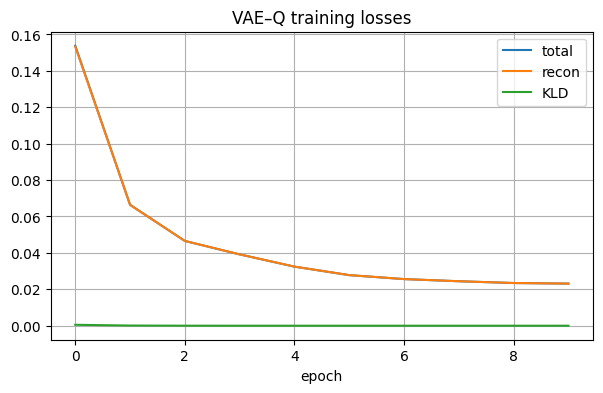

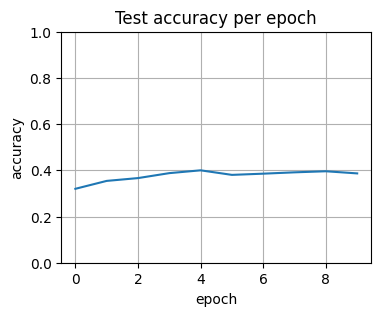

In [9]:
######################################################################
# 8. Training‑loss curves
######################################################################
plt.figure(figsize=(7,4))
plt.plot(history["loss"], label="total")
plt.plot(history["recon"], label="recon")
plt.plot(history["kld"], label="KLD")
plt.title("VAE–Q training losses"); plt.xlabel("epoch"); plt.grid(); plt.legend()
plt.show()

plt.figure(figsize=(4,3))
plt.plot(history["acc"]); plt.title("Test accuracy per epoch"); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.ylim(0,1); plt.grid()
plt.show()


In [10]:
######################################################################
# 9. Final threshold computation (on full train set)
######################################################################
model.eval()
cls_scores = {i:[] for i in range(NUM_CL)}
with torch.no_grad():
    for x,_,cid,_ in train_loader:
        x,cid = x.to(device), cid.to(device)
        recon,_,_ = model(x,cid)
        batch_score = torch.mean((x-recon)**2, dim=[1,2,3])
        for s,c in zip(batch_score, cid):
            cls_scores[c.item()].append(s.item())

THRESH = {c: np.percentile(cls_scores[c],90) for c in cls_scores}
print("saved per‑class thresholds.")


saved per‑class thresholds.


              precision    recall  f1-score   support

      Normal       0.29      0.87      0.43       467
     Anomaly       0.81      0.21      0.33      1258

    accuracy                           0.39      1725
   macro avg       0.55      0.54      0.38      1725
weighted avg       0.67      0.39      0.36      1725



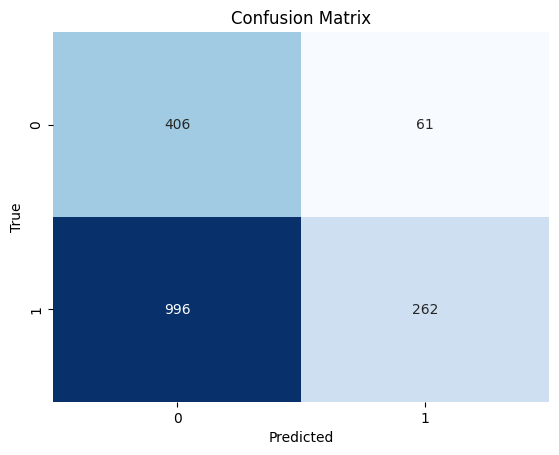

In [11]:
######################################################################
# 10. Full evaluation on test set
######################################################################
y_true, y_pred, y_score, y_cls = [], [], [], []
with torch.no_grad():
    for x,lbl,cid,_ in test_loader:
        x,cid = x.to(device), cid.to(device)
        recon,_,_ = model(x,cid)
        score = torch.mean((x-recon)**2).item()
        pred  = 1 if score>THRESH[cid.item()] else 0
        y_true.append(lbl.item()); y_pred.append(pred); y_score.append(score); y_cls.append(cid.item())

print(classification_report(y_true, y_pred, target_names=["Normal","Anomaly"]))

cm = confusion_matrix(y_true,y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix"); plt.show()


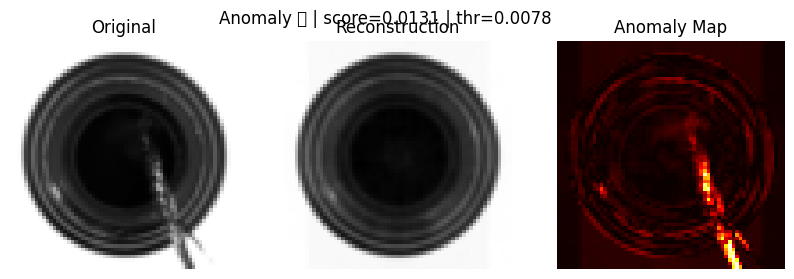

In [12]:
######################################################################
# 11. Visual helper – inspect a single image (ultra-robust version)
######################################################################
from pathlib import Path
import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image

# ---------- tiny util ------------------------------------------------
def _extract_path(sample):
    """
    Return the first element in `sample` that looks like a filesystem path.
    """
    for elem in sample:
        if isinstance(elem, (str, Path)) and os.sep in str(elem):
            return str(elem)
    raise TypeError("Couldn’t find a path string/Path object in sample "
                    f"(sample={sample})")

# ---------- anomaly finder ------------------------------------------
def get_first_anomaly_path(ds, keywords=None):
    """
    Return the path of the first anomaly sample in `ds.samples`.

    Parameters
    ----------
    ds : torch.utils.data.Dataset
    keywords : Iterable[str] | None
        If supplied, pick the first sample whose *path* contains ANY of these
        substrings (case-insensitive).  Otherwise, return the first sample
        whose path does **not** contain 'good'.
    """
    for sample in ds.samples:
        path = _extract_path(sample).lower()

        if keywords:                         # user-supplied defect names
            if any(k.lower() in path for k in keywords):
                return path
        else:                                # generic: anything not 'good'
            if "good" not in path:
                return path

    raise ValueError("No anomaly sample found — adjust your keywords or "
                     "double-check the dataset.")

# ---------- visualiser ----------------------------------------------
def inspect(path):
    model.eval()
    img = Image.open(path).convert("RGB")
    x   = tfm(img).unsqueeze(0).to(device)

    # try to infer the class ID from the folder name in the path
    cls_name_candidates = [c for c in train_ds.classes if c in path]
    if not cls_name_candidates:
        raise ValueError("Couldn’t guess the class name from the path. "
                         "Make sure the class folder appears in the path.")
    cid = torch.tensor([train_ds.cls2idx[cls_name_candidates[0]]]).to(device)

    with torch.no_grad():
        recon, _, _ = model(x, cid)

    score = torch.mean((x - recon) ** 2).item()
    pred  = "Anomaly 🚨" if score > THRESH[cid.item()] else "Normal ✅"

    # build anomaly map
    orig = x.squeeze().cpu().numpy()
    rec  = recon.squeeze().cpu().numpy()
    amap = np.abs(orig - rec)

    # de-normalise for viz
    orig = (orig * 0.5) + 0.5
    rec  = (rec  * 0.5) + 0.5

    plt.figure(figsize=(10, 3))
    for i, (im, title) in enumerate(
        zip([orig, rec, amap], ["Original", "Reconstruction", "Anomaly Map"])
    ):
        plt.subplot(1, 3, i + 1)
        plt.imshow(im, cmap="gray" if i < 2 else "hot")
        plt.axis("off")
        plt.title(title)

    plt.suptitle(f"{pred} | score={score:.4f} | thr={THRESH[cid.item()]:.4f}")
    plt.show()

# --------------------------------------------------------------------
# EXAMPLE USAGE
# --------------------------------------------------------------------
# 1) “Whatever anomaly you find first” (anything not inside a 'good' folder)
example = get_first_anomaly_path(test_ds)
inspect(example)

# 2) Or target specific defect keywords:
# example = get_first_anomaly_path(test_ds, keywords=["crack", "hole"])
# inspect(example)


In [13]:
######################################################################
# 12. Save artefacts
######################################################################
torch.save(model.state_dict(), "vae_q_model.pth")
np.save("thresholds.npy", THRESH)
with open("class_to_idx.json","w") as f: json.dump(train_ds.cls2idx,f)
print("Model & thresholds saved.")


Model & thresholds saved.
